<a href="https://colab.research.google.com/github/Abdukamol0870/klass/blob/main/Klassifikatsiya_%26_klasterlash.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Github'dan ma'lumotni o'qish
url = "https://raw.githubusercontent.com/Abdukamol0870/klass/main/klass.csv"
df = pd.read_csv(url)

# Ustun nomlarini tozalash (bo'sh joylarni olib tashlaymiz)
df.columns = df.columns.str.strip()

# Xususiyatlarni (X) ajratib olamiz
X_columns = ['Daromad (x1)', 'Xarajat (x2)']
X = df[X_columns]

# Ma'lumotlarni standartlashtirish (Algoritmlar masofani aniq hisoblashi uchun)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Ma'lumotlar tayyor!")

Ma'lumotlar tayyor!


Klassifikatsiya: SVM (Support Vector Machine):

In [8]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 1. Ma'lumotlarni yuklash
url = "https://raw.githubusercontent.com/Abdukamol0870/klass/main/klass.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()

# 2. Ma'lumotlarni tozalash (MUHIM!)
# Faqat birinchi 6 ta qatorda 'y' (Kredit) raqam ekanligiga ishonch hosil qilamiz
# Agar u yerda ham yozuv bo'lsa, ularni raqamga aylantiramiz
df['Kredit (y - Faqat SVM uchun)'] = pd.to_numeric(df['Kredit (y - Faqat SVM uchun)'], errors='coerce')

# 3. O'qitish to'plami (Train set - faqat raqamli qatorlar)
train_data = df.dropna(subset=['Kredit (y - Faqat SVM uchun)'])
X_train = train_data[['Daromad (x1)', 'Xarajat (x2)']]
y_train = train_data['Kredit (y - Faqat SVM uchun)']

# 4. Bashorat to'plami (Test set - Kredit ustuni bo'sh yoki '?' bo'lgan qatorlar)
test_data = df[df['Kredit (y - Faqat SVM uchun)'].isna()]
X_test = test_data[['Daromad (x1)', 'Xarajat (x2)']]

# 5. Standartlashtirish
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. SVM Modelini o'qitish
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train)

# 7. Bashorat
predictions = svm_model.predict(X_test_scaled)
print("7 va 8-mijozlar uchun SVM natijasi:", predictions)

7 va 8-mijozlar uchun SVM natijasi: [0. 0.]


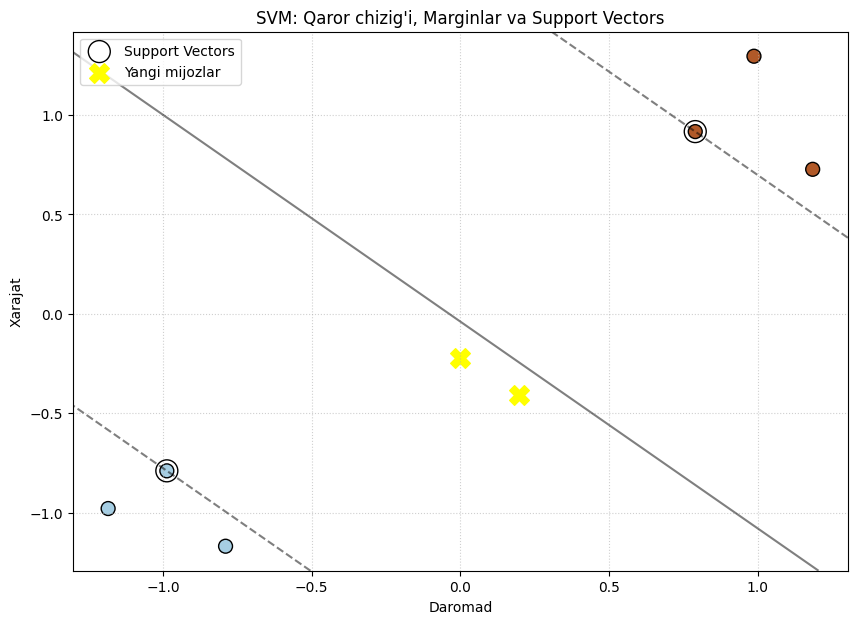

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# 1. Modelni qayta o'qitish (Chiziqli SVM)
clf = svm.SVC(kernel='linear', C=1000)
clf.fit(X_train_scaled, y_train)

# 2. Grafik chizish
plt.figure(figsize=(10, 7))
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, s=100, cmap=plt.cm.Paired, edgecolors='k')

# Grafik chegaralarini aniqlash
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# To'r (grid) yaratish
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

# Qaror chizig'i va Marginlarni chizish
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# Support Vector'larni belgilash (aylana bilan)
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=250,
           linewidth=1, facecolors='none', edgecolors='k', label="Support Vectors")

# Yangi mijozlarni (7-8) qo'shish
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c='yellow', marker='X', s=200, label="Yangi mijozlar")

plt.title("SVM: Qaror chizig'i, Marginlar va Support Vectors")
plt.xlabel("Daromad")
plt.ylabel("Xarajat")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Klasterlash: K-Means:

In [4]:
from sklearn.cluster import KMeans

# Modelni yaratish (Mijozlarni 2 ta guruhga bo'lamiz)
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)

# Barcha 8 ta mijozni klasterlarga ajratish
clusters = kmeans.fit_predict(X_scaled)

# Natijani asosiy jadvalga qo'shish
df['Klaster_ID'] = clusters

print("\n--- K-Means Natijalari ---")
print(df[['Mijoz ID', 'Daromad (x1)', 'Xarajat (x2)', 'Klaster_ID']])


--- K-Means Natijalari ---
   Mijoz ID  Daromad (x1)  Xarajat (x2)  Klaster_ID
0         1            20            30           0
1         2            25            35           0
2         3            30            25           0
3         4            70            80           1
4         5            80            75           1
5         6            75            90           1
6         7            50            50           0
7         8            55            45           0


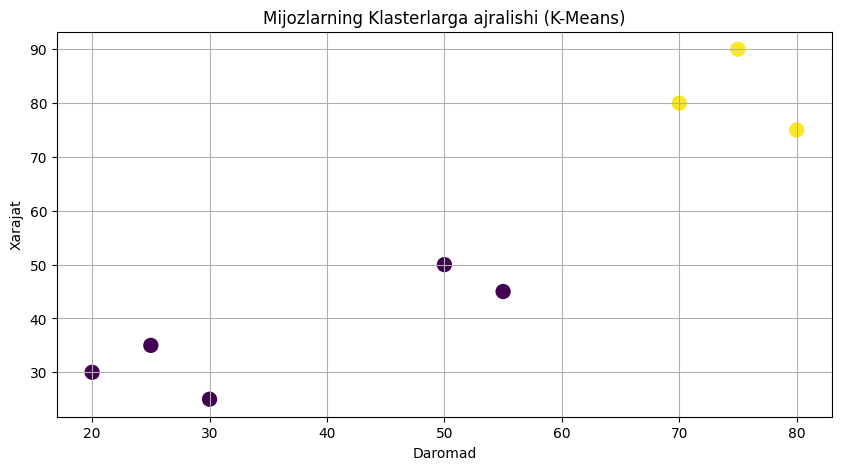

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Klasterlarni chizish
plt.scatter(df['Daromad (x1)'], df['Xarajat (x2)'], c=df['Klaster_ID'], cmap='viridis', s=100)
plt.title("Mijozlarning Klasterlarga ajralishi (K-Means)")
plt.xlabel("Daromad")
plt.ylabel("Xarajat")
plt.grid(True)
plt.show()